# E-Commerce Recommendation System

Building and tuning three models on the user behavior dataset:
regression to predict rating, logistic regression to predict purchase,
and K-Means to segment customers into behavior groups.

### Import libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from scipy.sparse import coo_matrix

### Load the dataset

In [2]:
df = pd.read_csv('ecommerce_user_behavior_8000.csv')
df.columns

Index(['user_id', 'age', 'gender', 'device_type', 'time_on_site',
       'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen',
       'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate',
       'purchase'],
      dtype='str')

In [3]:
df.shape

(8000, 14)

In [4]:
df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


### Rename columns for consistency

In [5]:
df.rename(columns={'time_on_site': 'Browsing_Time', 'ratings': 'Rating', 'purchase': 'Purchase_Status'}, inplace=True)

In [6]:
df.head()

,user_id,age,gender,device_type,Browsing_Time,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,Purchase_Status
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


### Feature descriptions

This dataset tracks user demographics, session engagement, and marketing
touchpoints, and the goal is to predict user actions and segment customers.

**Demographics & device**
- `user_id`: unique customer identifier, dropped before training since it has no predictive value
- `age`: customer's age
- `gender`: customer's gender, needs encoding before modeling
- `device_type`: device used to browse (mobile, desktop, tablet)

**Session engagement**
- `Browsing_Time` (originally `time_on_site`): time spent on the site in the current session, usually a strong signal of intent to buy
- `pages_viewed`: number of pages viewed during the visit
- `avg_session_time`: this user's historical average session length
- `bounce_rate`: percentage of visits where the user leaves after one page, a negative signal

**Cart & marketing signals**
- `previous_purchases`: number of past orders, a measure of loyalty
- `cart_items`: number of items added to cart in this session, a strong purchase predictor
- `discount_seen`: whether a discount was shown to the user (1/0)
- `ad_clicked`: whether the user arrived via an ad (1/0)
- `returning_user`: whether this is a returning visitor (1/0)

**Targets**
- `Rating`: rating left by the customer (target for regression)
- `Purchase_Status` (originally `purchase`): whether the session ended in a purchase (target for classification)

## Preprocessing & EDA

In [7]:
df.drop(columns=["user_id"], inplace=True)

In [8]:
df.head()

,age,gender,device_type,Browsing_Time,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,Purchase_Status
0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 7840 non-null   float64
 1   gender              7840 non-null   str    
 2   device_type         7840 non-null   str    
 3   Browsing_Time       7840 non-null   float64
 4   pages_viewed        7840 non-null   float64
 5   previous_purchases  7840 non-null   float64
 6   cart_items          7840 non-null   float64
 7   discount_seen       7840 non-null   float64
 8   ad_clicked          7840 non-null   float64
 9   returning_user      7840 non-null   float64
 10  avg_session_time    7840 non-null   float64
 11  bounce_rate         7840 non-null   float64
 12  Purchase_Status     7840 non-null   float64
dtypes: float64(11), str(2)
memory usage: 901.1 KB


#### Handling null values

In [10]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["device_type"] = df["device_type"].fillna(df["device_type"].mode()[0])

In [11]:
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum()

age                   0
gender                0
device_type           0
Browsing_Time         0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
Purchase_Status       0
dtype: int64

### One-hot encoding

In [13]:
df = pd.get_dummies(df, columns=["gender", "device_type"], drop_first=True, dtype=int)

In [14]:
df.head()

,age,Browsing_Time,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,Purchase_Status,gender_Male,device_type_Mobile,device_type_Tablet
0,56.0,12.90,8.0,13.0,1.0,1.0,1.0,0.0,6.97,28.18,1.0,0,0,0
1,46.0,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0,1,1,0
2,32.0,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0,0,1,0
3,25.0,22.71,5.0,10.0,1.0,0.0,0.0,1.0,14.30,79.03,1.0,0,1,0
4,38.0,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0,0,1,0


### Creating the rating target

The raw dataset doesn't include a rating column, so one is built from a
weighted mix of purchase history, browsing time, bounce rate, and whether
the session ended in a purchase, then rescaled to a 1-5 range.

In [15]:
np.random.seed(42)
base_score = (df['previous_purchases'] * 0.4) + (df['Browsing_Time'] * 0.3) - (df['bounce_rate'] * 0.2) + (df['Purchase_Status'] * 1.5)

# rescale to a 1.0-5.0 rating
min_b, max_b = base_score.min(), base_score.max()
df['Rating'] = 1.0 + 4.0 * (base_score - min_b) / (max_b - min_b)
df['Rating'] = df['Rating'].round(1)

In [16]:
df.head()

,age,Browsing_Time,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,Purchase_Status,gender_Male,device_type_Mobile,device_type_Tablet,Rating
0,56.0,12.90,8.0,13.0,1.0,1.0,1.0,0.0,6.97,28.18,1.0,0,0,0,3.7
1,46.0,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0,1,1,0,2.0
2,32.0,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0,0,1,0,2.3
3,25.0,22.71,5.0,10.0,1.0,0.0,0.0,1.0,14.30,79.03,1.0,0,1,0,2.7
4,38.0,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0,0,1,0,3.5


### Checking purchase status balance

In [17]:
df["Purchase_Status"].value_counts()

Purchase_Status
1.0    7987
0.0      13
Name: count, dtype: int64

### Handling data imbalance

The purchase rate generated above skews high, so low-intent sessions
(high bounce rate or a low rating) are pushed back towards "not
purchased", keeping a small share as natural exceptions.

In [18]:
np.random.seed(42)

# a session with high bounce rate or a low rating is unlikely to have converted
low_intent_mask = (df['bounce_rate'] > 55) | (df['Rating'] < 2.5)

# flip about 75% of those low-intent sessions to "not purchased", leave the rest as noise
random_rebalance = np.random.choice([0, 1], size=low_intent_mask.sum(), p=[0.75, 0.25])
df.loc[low_intent_mask, 'Purchase_Status'] = random_rebalance

print("=========================================")
print("      UPDATED DATASET CLASS BALANCE      ")
print("=========================================")
print(df['Purchase_Status'].value_counts())

      UPDATED DATASET CLASS BALANCE      
Purchase_Status
1.0    5367
0.0    2633
Name: count, dtype: int64


### Distribution of key continuous behavior variables

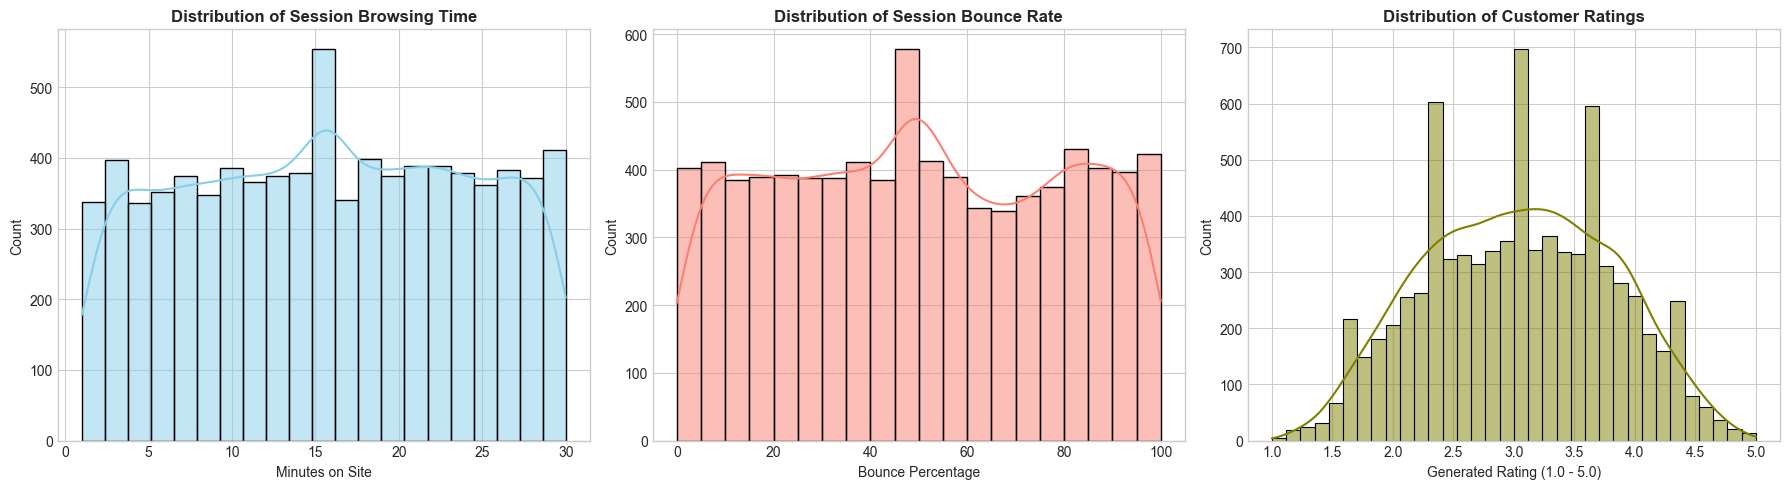

In [19]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Browsing_Time'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Session Browsing Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutes on Site')

sns.histplot(df['bounce_rate'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Session Bounce Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bounce Percentage')

sns.histplot(df['Rating'], kde=True, color='olive', ax=axes[2])
axes[2].set_title('Distribution of Customer Ratings', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Generated Rating (1.0 - 5.0)')
plt.tight_layout()
plt.show()

### Purchase status after rebalancing

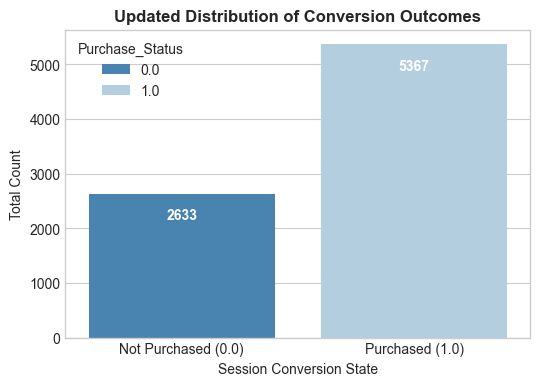

In [20]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Purchase_Status', hue="Purchase_Status", data=df, palette='Blues_r')
plt.title('Updated Distribution of Conversion Outcomes', fontsize=12, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Not Purchased (0.0)', 'Purchased (1.0)'])
plt.xlabel('Session Conversion State')
plt.ylabel('Total Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() - 400),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.show()

### Feature correlation heatmap

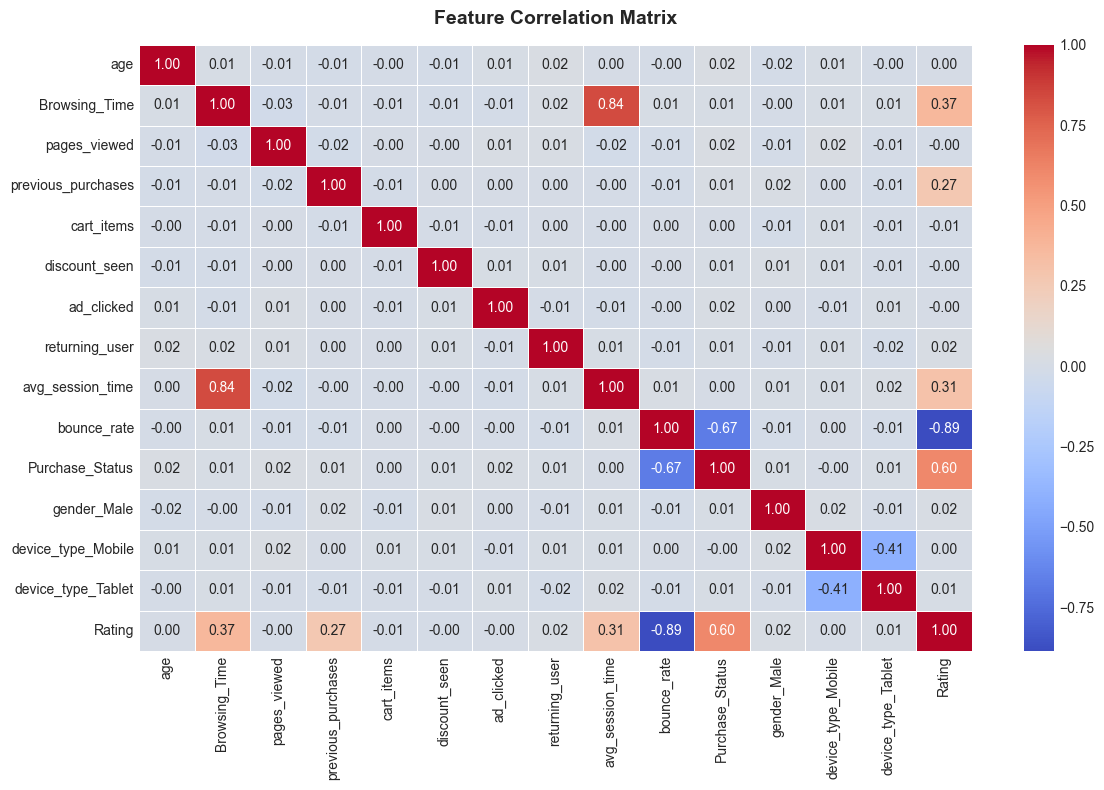

In [21]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Part A: Regression (Rating Prediction)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# features exclude the identifiers and both targets
X_reg = df.drop(columns=['user_id', 'Rating', 'Purchase_Status'], errors='ignore')
y_reg = df['Rating']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

### Predict and evaluate

In [23]:
y_pred_reg = ridge_model.predict(X_test_reg)

print("--- Regression Metrics ---")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")
print(f"R² Score: {r2_score(y_test_reg, y_pred_reg):.4f}")

--- Regression Metrics ---
MAE:  0.0256
RMSE: 0.0297
R² Score: 0.9985


### Hyperparameter optimization for Ridge Regression

Using `GridSearchCV` with 5-fold cross-validation to test a range of alpha
values, so the model stays regularized enough to handle collinear features
without overfitting.

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_reg = df.drop(columns=['Rating'])
y_reg = df['Rating']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}

ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_reg, y_train_reg)

print("=========================================")
print("      RIDGE REGRESSION TUNING RESULTS    ")
print("=========================================")
print(f"Optimal Alpha Selected: {ridge_grid.best_params_['alpha']}")

best_ridge = ridge_grid.best_estimator_
reg_preds = best_ridge.predict(X_test_reg)
print(f"Optimized Test RMSE:   {np.sqrt(mean_squared_error(y_test_reg, reg_preds)):.4f}")
print(f"Optimized Test R² Score: {r2_score(y_test_reg, reg_preds):.4f}\n")

      RIDGE REGRESSION TUNING RESULTS    
Optimal Alpha Selected: 100.0
Optimized Test RMSE:   0.0297
Optimized Test R² Score: 0.9985



# Part B: Classification (Purchase Prediction)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

X_class = df.drop(columns=['user_id', 'Purchase_Status'], errors='ignore')
y_class = df['Purchase_Status']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

log_reg = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=42)
log_reg.fit(X_train_cls, y_train_cls)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

### Predict and evaluate

In [26]:
y_pred_cls = log_reg.predict(X_test_cls)
y_prob_cls = log_reg.predict_proba(X_test_cls)[:, 1]

print("=========================================")
print("     CLASSIFICATION BASELINE REPORT      ")
print("=========================================")
print(f"Accuracy:  {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print(f"Precision: {precision_score(y_test_cls, y_pred_cls):.4f}")
print(f"Recall:    {recall_score(y_test_cls, y_pred_cls):.4f}")
print(f"F1-Score:  {f1_score(y_test_cls, y_pred_cls):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_cls, y_prob_cls):.4f}\n")

     CLASSIFICATION BASELINE REPORT      
Accuracy:  0.8213
Precision: 0.8481
Recall:    0.8779
F1-Score:  0.8628
ROC-AUC:   0.9099



### Confusion matrix

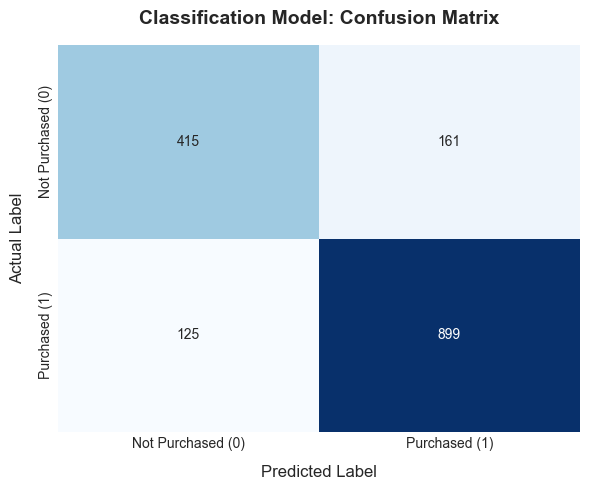

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Not Purchased (0)', 'Purchased (1)'],
            yticklabels=['Not Purchased (0)', 'Purchased (1)'])

plt.title('Classification Model: Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('Actual Label', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### Hyperparameter optimization for Logistic Regression

Using `GridSearchCV` to tune the regularization strength `C`, penalty type
(`l1` vs `l2`), and solver, optimizing for F1-Score on the rebalanced
dataset.

In [28]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

X_cls = df.drop(columns=['Purchase_Status'])
y_cls = df['Purchase_Status']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

log_reg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    log_reg_param_grid, cv=5, scoring='f1', n_jobs=-1
)
log_reg_grid.fit(X_train_cls, y_train_cls)

print("=========================================")
print("   LOGISTIC REGRESSION TUNING RESULTS    ")
print("=========================================")
print(f"Best Parameters Found: {log_reg_grid.best_params_}")

best_log_reg = log_reg_grid.best_estimator_
cls_preds = best_log_reg.predict(X_test_cls)
print(f"Optimized Accuracy: {accuracy_score(y_test_cls, cls_preds):.4f}")
print(f"Optimized F1-Score: {f1_score(y_test_cls, cls_preds):.4f}\n")

   LOGISTIC REGRESSION TUNING RESULTS    
Best Parameters Found: {'C': 0.001, 'penalty': 'l2', 'solver': 'saga'}
Optimized Accuracy: 0.8669
Optimized F1-Score: 0.8961



# Part C: Clustering (Customer Segmentation)

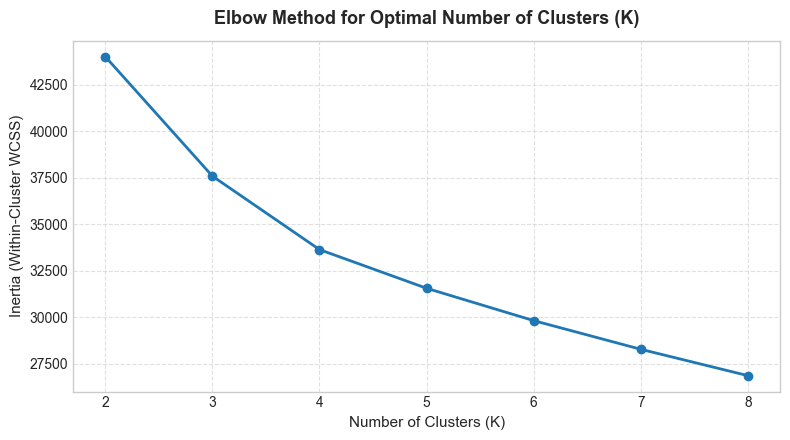

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_features = ['Browsing_Time', 'pages_viewed', 'previous_purchases',
                    'cart_items', 'avg_session_time', 'bounce_rate', 'Rating']
X_cluster = df[cluster_features]

# K-Means relies on distance, so features need to be on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertia_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.title('Elbow Method for Optimal Number of Clusters (K)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Inertia (Within-Cluster WCSS)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# k=4 chosen based on the elbow above
final_kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['Cluster_Labels'] = final_kmeans.fit_predict(X_scaled)

### Cluster quality

In [30]:
sil_score = silhouette_score(X_scaled, final_kmeans.labels_)

print("=========================================")
print("       CLUSTERING BASELINE REPORT        ")
print("=========================================")
print(f"Final Inertia (WCSS): {final_kmeans.inertia_:.4f}")
print(f"Silhouette Score:     {sil_score:.4f}\n")

       CLUSTERING BASELINE REPORT        
Final Inertia (WCSS): 33639.9377
Silhouette Score:     0.1642



### Cluster profiles

In [31]:
print("---------------------- Average Feature Profiles Per Customer Cluster -------------------")
profile_matrix = df.groupby('Cluster_Labels')[cluster_features].mean()
profile_matrix.round(2)

---------------------- Average Feature Profiles Per Customer Cluster -------------------


,Browsing_Time,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate,Rating
Cluster_Labels,,,,,,,
0,8.51,9.92,6.22,4.59,8.06,75.99,2.12
1,23.47,9.84,7.92,4.49,24.28,25.16,3.95
2,9.57,10.34,7.49,4.55,8.78,26.81,3.39
3,22.38,9.73,6.25,4.53,23.15,72.42,2.71


### Hyperparameter validation: choosing k

K-Means has no target variable to cross-validate against, so instead we
check a range of k values against inertia and silhouette score together
and pick the value that balances both.

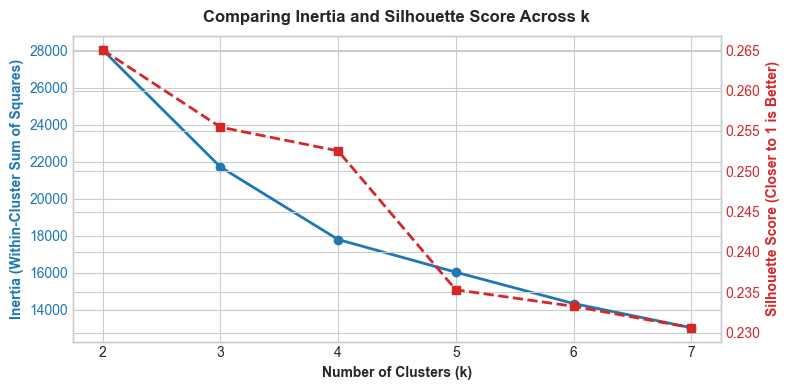

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_features = ['Browsing_Time', 'pages_viewed', 'avg_session_time', 'bounce_rate', 'Rating']
X_cluster = StandardScaler().fit_transform(df[cluster_features])

inertia_values = []
silhouette_avg_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=500, random_state=42)
    labels = km.fit_predict(X_cluster)
    inertia_values.append(km.inertia_)
    silhouette_avg_scores.append(silhouette_score(X_cluster, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color=color, fontweight='bold')
ax1.plot(k_range, inertia_values, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Closer to 1 is Better)', color=color, fontweight='bold')
ax2.plot(k_range, silhouette_avg_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparing Inertia and Silhouette Score Across k', fontsize=12, fontweight='bold', pad=10)
fig.tight_layout()
plt.show()